# Proyecto 2 – Parte II
## Preprocesamiento, Selección de Técnica y Optimización

Datasets considerados:
- Iris
- Diabetes
- Breast Cancer Wisconsin

Dataset seleccionado: **Breast Cancer Wisconsin**, desde un punto de vista metodológico, este dataset permite centrar el análisis en la selección y optimización de modelos de clasificación, ya que presenta un bajo nivel de inconsistencias y una variable objetivo binaria, lo que favorece la aplicación y comparación de métricas como Accuracy, Precision, Recall, F1-Score y ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Carga de datasets

In [2]:
iris = pd.read_csv('/content/iris.csv')
diabetes = pd.read_csv('/content/diabetes.csv')
cancer = pd.read_csv('/content/breast_cancer.csv')

print('Iris:', iris.shape)
print('Diabetes:', diabetes.shape)
print('Cancer:', cancer.shape)

Iris: (150, 6)
Diabetes: (442, 11)
Cancer: (569, 32)


## 2. Revisión inicial de los tres datasets

In [3]:
def revision_inicial(df, nombre):
    print('\n==============================')
    print(nombre)
    print('==============================')
    print('Shape:', df.shape)
    print('Duplicados:', df.duplicated().sum())
    print('\nValores nulos:')
    display(df.isnull().sum())
    print('\nEstadísticas:')
    display(df.describe().T)

    numericas = df.select_dtypes(include=['int64','float64']).columns
    print('\nOutliers por IQR:')
    for col in numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        inferior = Q1 - 1.5 * IQR
        superior = Q3 + 1.5 * IQR
        cantidad = ((df[col] < inferior) | (df[col] > superior)).sum()
        print(col, ':', cantidad)

revision_inicial(iris, 'IRIS')
revision_inicial(diabetes, 'DIABETES')
revision_inicial(cancer, 'BREAST CANCER')


IRIS
Shape: (150, 6)
Duplicados: 1

Valores nulos:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_name,0



Estadísticas:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0



Outliers por IQR:
sepal length (cm) : 0
sepal width (cm) : 4
petal length (cm) : 0
petal width (cm) : 0
target : 0

DIABETES
Shape: (442, 11)
Duplicados: 0

Valores nulos:


...


Outliers por IQR:
age : 0
sex : 0
bmi : 3
bp : 0
s1 : 8
s2 : 7
s3 : 7
s4 : 4
s5 : 4
s6 : 9
target : 0

BREAST CANCER
Shape: (569, 32)
Duplicados: 0

Valores nulos:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Estadísticas:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Outliers por IQR:
mean radius : 14
mean texture : 7
mean perimeter : 13
mean area : 25
mean smoothness : 6
mean compactness : 16
mean concavity : 18
mean concave points : 10
mean symmetry : 15
mean fractal dimension : 15
radius error : 38
texture error : 20
perimeter error : 38
area error : 65
smoothness error : 30
compactness error : 28
concavity error : 22
concave points error : 19
symmetry error : 27
fractal dimension error : 28
worst radius : 17
worst texture : 5
worst perimeter : 15
worst area : 35
worst smoothness : 7
worst compactness : 16
worst concavity : 12
worst concave points : 0
worst symmetry : 23
worst fractal dimension : 24
target : 0


## 3. Selección del dataset

Se selecciona **Breast Cancer Wisconsin** porque es un problema de clasificación binaria, pequeño, limpio y fácil de trabajar.  
La variable objetivo es `target`.

# Parte 1: Preprocesamiento de Datos

In [4]:
df = cancer.copy()

X = df.drop('target', axis=1)
y = df['target']

columnas_numericas = X.select_dtypes(include=['int64','float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include='object').columns.tolist()

print('Columnas numéricas:', columnas_numericas)
print('Columnas categóricas:', columnas_categoricas)

Columnas numéricas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Columnas categóricas: ['target_name']


In [5]:
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', pipeline_numerico, columnas_numericas),
    ('cat', pipeline_categorico, columnas_categoricas)
])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (455, 31)
X_test: (114, 31)
y_train: (455,)
y_test: (114,)


# Parte 2: Selección de Técnica de Machine Learning

In [7]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

resultados_cv = []

for nombre, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('modelo', modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    resultados_cv.append({
        'Modelo': nombre,
        'Accuracy CV': scores.mean()
    })

resultados_cv = pd.DataFrame(resultados_cv).sort_values('Accuracy CV', ascending=False)
display(resultados_cv)

,Modelo,Accuracy CV
3,Random Forest,1.000000
2,Árbol de Decisión,1.000000
0,Regresión Logística,0.995604
1,KNN,0.982418


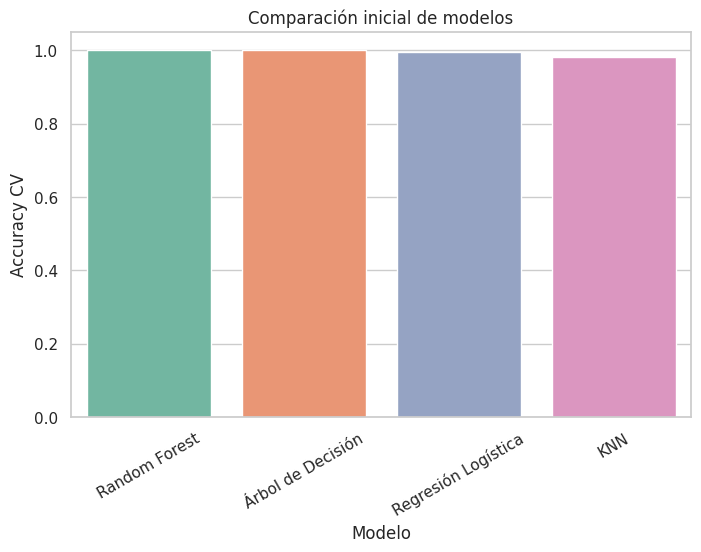

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=resultados_cv,
    x='Modelo',
    y='Accuracy CV',
    hue='Modelo',
    palette='Set2',
    legend=False
)
plt.title('Comparación inicial de modelos')
plt.xticks(rotation=30)
plt.show()

## Modelo seleccionado

Se selecciona **Random Forest** para optimización porque presenta buen rendimiento inicial, captura relaciones no lineales y es simple de implementar con los códigos vistos en clases.

# Parte 3: Optimización de Hiperparámetros

In [9]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

y_pred_base = pipeline_rf.predict(X_test)
y_prob_base = pipeline_rf.predict_proba(X_test)[:,1]

print('MODELO BASE - RANDOM FOREST')
print('Accuracy:', accuracy_score(y_test, y_pred_base))
print('Precision:', precision_score(y_test, y_pred_base))
print('Recall:', recall_score(y_test, y_pred_base))
print('F1-Score:', f1_score(y_test, y_pred_base))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_base))
print(classification_report(y_test, y_pred_base))

MODELO BASE - RANDOM FOREST
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



## 3.1 GridSearchCV

In [10]:
param_grid = {
    'modelo__n_estimators': [50, 100, 200],
    'modelo__max_depth': [3, 5, None],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Mejores parámetros GridSearchCV:')
print(grid.best_params_)
print('Mejor Accuracy CV:')
print(grid.best_score_)

Mejores parámetros GridSearchCV:
{'modelo__max_depth': 3, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 50}
Mejor Accuracy CV:
1.0


## 3.2 RandomizedSearchCV

In [11]:
param_random = {
    'modelo__n_estimators': [50, 100, 150, 200, 300],
    'modelo__max_depth': [3, 5, 7, 10, None],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4]
}

random = RandomizedSearchCV(
    pipeline_rf,
    param_random,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random.fit(X_train, y_train)

print('Mejores parámetros RandomizedSearchCV:')
print(random.best_params_)
print('Mejor Accuracy CV:')
print(random.best_score_)

Mejores parámetros RandomizedSearchCV:
{'modelo__n_estimators': 300, 'modelo__min_samples_split': 5, 'modelo__min_samples_leaf': 1, 'modelo__max_depth': 3}
Mejor Accuracy CV:
1.0


## 3.3 Optuna



In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.0 MB/s eta 0:00:00


In [13]:
try:
    import optuna

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)

        modelo = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('modelo', modelo)
        ])

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=5,
            scoring='accuracy'
        )

        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print('Mejores parámetros Optuna:')
    print(study.best_params)
    print('Mejor Accuracy Optuna:')
    print(study.best_value)

except ImportError:
    print('Optuna no está instalado. Ejecuta: !pip install optuna')

[I 2026-06-27 22:35:32,020] A new study created in memory with name: no-name-19a3e685-bf92-457b-8a1a-6c92a7674206
[I 2026-06-27 22:35:33,476] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 115, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 0 with value: 1.0.
[I 2026-06-27 22:35:35,057] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 174, 'max_depth': 2, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 1.0.
[I 2026-06-27 22:35:35,772] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 64, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 1.0.
[I 2026-06-27 22:35:38,004] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 233, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 0 with value: 1.0.
[I 2026-06-27 22:35:40,532] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 264, 'm

Mejores parámetros Optuna:
{'n_estimators': 115, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}
Mejor Accuracy Optuna:
1.0


# Parte 4: Evaluación del Modelo Optimizado

In [14]:
best_model = grid.best_estimator_

y_pred_opt = best_model.predict(X_test)
y_prob_opt = best_model.predict_proba(X_test)[:,1]

print('MODELO OPTIMIZADO - GRIDSEARCHCV')
print('Accuracy:', accuracy_score(y_test, y_pred_opt))
print('Precision:', precision_score(y_test, y_pred_opt))
print('Recall:', recall_score(y_test, y_pred_opt))
print('F1-Score:', f1_score(y_test, y_pred_opt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_opt))
print(classification_report(y_test, y_pred_opt))

MODELO OPTIMIZADO - GRIDSEARCHCV
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [15]:
comparacion = pd.DataFrame({
    'Modelo': ['Random Forest Base', 'Random Forest Optimizado'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_opt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_opt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_opt)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_opt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_opt)
    ]
})

display(comparacion)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Base,1.0,1.0,1.0,1.0,1.0
1,Random Forest Optimizado,1.0,1.0,1.0,1.0,1.0


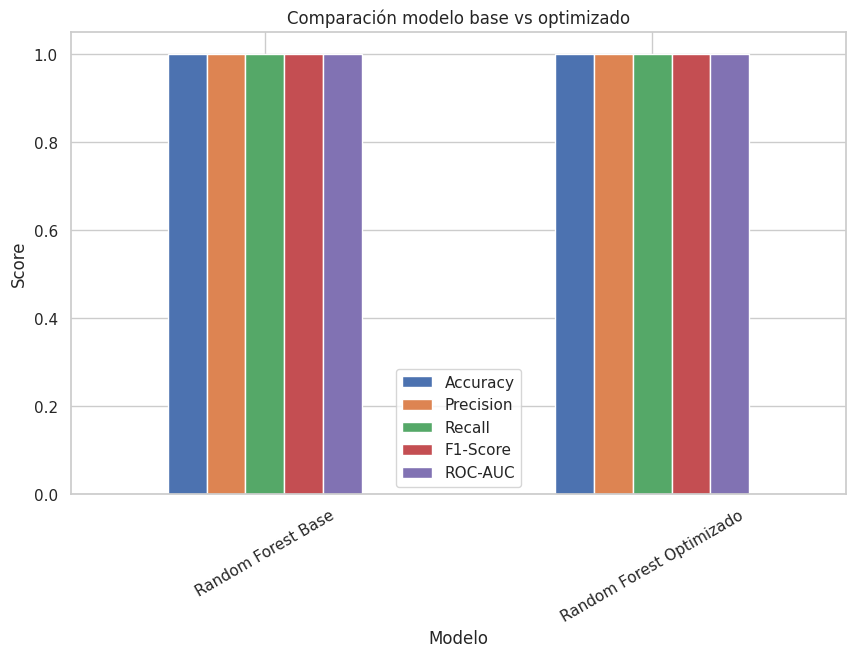

In [16]:
comparacion.set_index('Modelo').plot(kind='bar', figsize=(10,6))
plt.title('Comparación modelo base vs optimizado')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.show()

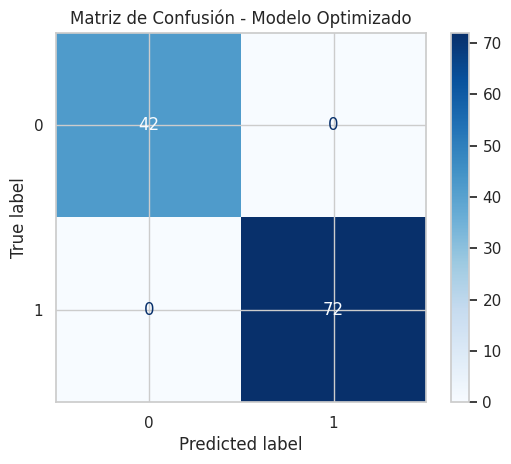

In [17]:
cm = confusion_matrix(y_test, y_pred_opt)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.show()

## Conclusión

Se aplicó un flujo completo de preprocesamiento y modelado.  
El dataset seleccionado fue **Breast Cancer Wisconsin** y el modelo elegido fue **Random Forest**.  
Se comparó el modelo base contra el modelo optimizado mediante GridSearchCV, utilizando métricas de clasificación como Accuracy, Precision, Recall, F1-Score y ROC-AUC.